In [ ]:
import json
import random
import pandas as pd

def generate_labeled_requests(policy_json, num_allow=3, num_deny=2):
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions to extract and normalize values
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            # If no action specified, extract service from other actions in policy or use generic
            all_actions = []
            for s in statements:
                stmt_actions = s.get("Action", [])
                if isinstance(stmt_actions, list):
                    all_actions.extend(stmt_actions)
                elif stmt_actions:
                    all_actions.append(stmt_actions)
            
            if all_actions:
                # Use an action from the policy
                return random.choice(all_actions)
            else:
                # Fallback to generic action
                return "*"
        
        # Preserve list structure
        if isinstance(action, list):
            return action  # Return the entire list
        return action  # Return single string

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            # If no resource specified, extract from other statements or use generic
            all_resources = []
            for s in statements:
                stmt_resources = s.get("Resource", [])
                if isinstance(stmt_resources, list):
                    all_resources.extend(stmt_resources)
                elif stmt_resources:
                    all_resources.append(stmt_resources)
            
            if all_resources:
                # Use a resource from the policy
                resource = random.choice(all_resources)
            else:
                # Fallback to generic resource
                resource = "*"
        
        # Preserve list structure
        if isinstance(resource, list):
            # Process each resource in the list
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            # Single resource
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            # If no principal specified, use a generic one
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            # Handle {"AWS": "arn:..."} or {"AWS": ["arn1", "arn2"]} format
            values = list(principal.values())[0]
            return values  # Preserve list structure if it exists
        return principal  # Return as-is (could be string or list)

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            # If no conditions in this statement, return empty dict (no default condition)
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1  # Slightly modify to ensure it should still pass
                else:
                    flattened[key] = val
        return flattened

    # Generate allowed requests
    for _ in range(num_allow):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        requests.append({
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "Condition": get_condition(stmt),
            "ExpectedDecision": "Allow"
        })

    # Generate denied requests
    for _ in range(num_deny):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Choose what to violate
        violation_type = random.choice(["action", "resource", "principal", "condition"])
        
        if violation_type == "action":
            # Modify action(s)
            if isinstance(action, list):
                # Add invalid actions to the list or modify existing ones
                modified_actions = []
                for act in action:
                    if random.random() < 0.7:  # 70% chance to make invalid
                        modified_actions.append(act + ".Invalid")
                    else:
                        modified_actions.append(act)
                # Also add some completely forbidden actions
                service = action[0].split(':')[0] if action else "s3"
                forbidden_actions = {
                    "s3": ["s3:DeleteBucket", "s3:DeleteObject"],
                    "logs": ["logs:DeleteLogGroup", "logs:PutRetentionPolicy"],
                    "ec2": ["ec2:TerminateInstances", "ec2:DeleteSecurityGroup"],
                    "iam": ["iam:DeleteUser", "iam:CreateRole"]
                }
                if service in forbidden_actions:
                    modified_actions.extend(random.sample(forbidden_actions[service], 1))
                action = modified_actions
            else:
                # Single action - make it invalid
                action = action + ".Invalid"
                
        elif violation_type == "resource":
            # Modify resource(s)
            if isinstance(resource, list):
                modified_resources = []
                for res in resource:
                    # Change to unauthorized resource
                    if "s3:::" in res:
                        modified_resources.append("arn:aws:s3:::unauthorized-bucket/forbidden-object")
                    elif "logs:" in res:
                        modified_resources.append("arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*")
                    else:
                        modified_resources.append("arn:aws:s3:::invalid-bucket/unknown-object")
                resource = modified_resources
            else:
                # Single resource
                if "s3:::" in resource:
                    resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
                elif "logs:" in resource:
                    resource = "arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*"
                else:
                    resource = "arn:aws:s3:::invalid-bucket/unknown-object"
                    
        elif violation_type == "principal":
            # Modify principal
            if isinstance(principal, list):
                principal = ["arn:aws:iam::999999999:user/unauthorized-user"]
            else:
                principal = "arn:aws:iam::999999999:user/unauthorized-user"
                
        elif violation_type == "condition":
            # Violate condition constraints
            violated_condition = {}
            for key, val in condition.items():
                if isinstance(val, (int, float)):
                    # Violate numeric conditions
                    if "MaxKeys" in key:
                        violated_condition[key] = val + 50  # Exceed the limit
                    else:
                        violated_condition[key] = val * 10  # Make it much larger
                else:
                    violated_condition[key] = "InvalidValue"
            condition = violated_condition
        
        requests.append({
            "Effect": "allow",  # Still requesting allow, but should be denied
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "Condition": condition,
            "ExpectedDecision": "Deny"
        })

    random.shuffle(requests)
    return {"Requests": requests}

# Example policy with lists
policy_input = '''
{
    "Version": "2012-10-17",
    "Statement": [
        {
            "Principal": "VisualEditor1",
            "Effect": "Allow",
            "Action": [
                "s3:Get*",
                "s3:List*",
                "s3:Put*"
            ],
            "Resource": [
                "arn:aws:s3:::*",
                "arn:aws:s3:::*/*"
            ]
        }
    ]
}
    
'''

generated = generate_labeled_requests(policy_input, num_allow=3, num_deny=2)

# Print each request one at a time in the specified format
for i, req in enumerate(generated["Requests"], 1):
    # Remove ExpectedDecision from output
    clean_req = {k: v for k, v in req.items() if k != 'ExpectedDecision'}
    
    # Only include fields that have values
    final_req = {}
    for key in ["Effect", "Principal", "Action", "Resource", "Condition"]:
        if key in clean_req and clean_req[key]:
            final_req[key] = clean_req[key]
    
    # Format as single request JSON
    single_request = {"Requests": [final_req]}
    
    print(f"Request {i} (Expected: {req['ExpectedDecision']}):")
    print(json.dumps(single_request, indent=4))
    print()

# Summary
print("="*50)
print("SUMMARY:")
df = pd.DataFrame(generated["Requests"])
print(df['ExpectedDecision'].value_counts())

print("")

Request 1 (Expected: Deny):
{
    "Requests": [
        {
            "Effect": "allow",
            "Principal": "arn:aws:iam::999999999:user/unauthorized-user",
            "Action": [
                "s3:Get*",
                "s3:List*",
                "s3:Put*"
            ],
            "Resource": [
                "arn:aws:s3:::object-75",
                "arn:aws:s3:::object-93/object-93"
            ]
        }
    ]
}

Request 2 (Expected: Allow):
{
    "Requests": [
        {
            "Effect": "allow",
            "Principal": "VisualEditor1",
            "Action": [
                "s3:Get*",
                "s3:List*",
                "s3:Put*"
            ],
            "Resource": [
                "arn:aws:s3:::object-93",
                "arn:aws:s3:::object-100/object-100"
            ]
        }
    ]
}

Request 3 (Expected: Allow):
{
    "Requests": [
        {
            "Effect": "allow",
            "Principal": "VisualEditor1",
            "Action": [
   

In [30]:
import json
import random
import pandas as pd
import os
import argparse

def generate_labeled_requests(policy_json, num_allow=3, num_deny=2):
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions to extract and normalize values
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            # If no action specified, extract service from other actions in policy or use generic
            all_actions = []
            for s in statements:
                stmt_actions = s.get("Action", [])
                if isinstance(stmt_actions, list):
                    all_actions.extend(stmt_actions)
                elif stmt_actions:
                    all_actions.append(stmt_actions)
            
            if all_actions:
                # Use an action from the policy
                return random.choice(all_actions)
            else:
                # Fallback to generic action
                return "*"
        
        # Preserve list structure
        if isinstance(action, list):
            return action  # Return the entire list
        return action  # Return single string

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            # If no resource specified, extract from other statements or use generic
            all_resources = []
            for s in statements:
                stmt_resources = s.get("Resource", [])
                if isinstance(stmt_resources, list):
                    all_resources.extend(stmt_resources)
                elif stmt_resources:
                    all_resources.append(stmt_resources)
            
            if all_resources:
                # Use a resource from the policy
                resource = random.choice(all_resources)
            else:
                # Fallback to generic resource
                resource = "*"
        
        # Preserve list structure
        if isinstance(resource, list):
            # Process each resource in the list
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            # Single resource
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            # If no principal specified, use a generic one
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            # Handle {"AWS": "arn:..."} or {"AWS": ["arn1", "arn2"]} format
            values = list(principal.values())[0]
            return values  # Preserve list structure if it exists
        return principal  # Return as-is (could be string or list)

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            # If no conditions in this statement, return empty dict (no default condition)
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1  # Slightly modify to ensure it should still pass
                else:
                    flattened[key] = val
        return flattened

    # Generate allowed requests
    for _ in range(num_allow):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        request = {
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "ExpectedDecision": "Allow"
        }
        
        # Only add condition if it exists
        condition = get_condition(stmt)
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    # Generate denied requests
    for _ in range(num_deny):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Choose what to violate
        violation_type = random.choice(["action", "resource", "principal", "condition"])
        
        if violation_type == "action":
            # Modify action(s)
            if isinstance(action, list):
                # Add invalid actions to the list or modify existing ones
                modified_actions = []
                for act in action:
                    if random.random() < 0.7:  # 70% chance to make invalid
                        modified_actions.append(act + ".Invalid")
                    else:
                        modified_actions.append(act)
                # Also add some completely forbidden actions
                service = action[0].split(':')[0] if action else "s3"
                forbidden_actions = {
                    "s3": ["s3:DeleteBucket", "s3:DeleteObject"],
                    "logs": ["logs:DeleteLogGroup", "logs:PutRetentionPolicy"],
                    "ec2": ["ec2:TerminateInstances", "ec2:DeleteSecurityGroup"],
                    "iam": ["iam:DeleteUser", "iam:CreateRole"]
                }
                if service in forbidden_actions:
                    modified_actions.extend(random.sample(forbidden_actions[service], 1))
                action = modified_actions
            else:
                # Single action - make it invalid
                action = action + ".Invalid"
                
        elif violation_type == "resource":
            # Modify resource(s)
            if isinstance(resource, list):
                modified_resources = []
                for res in resource:
                    # Change to unauthorized resource
                    if "s3:::" in res:
                        modified_resources.append("arn:aws:s3:::unauthorized-bucket/forbidden-object")
                    elif "logs:" in res:
                        modified_resources.append("arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*")
                    else:
                        modified_resources.append("arn:aws:s3:::invalid-bucket/unknown-object")
                resource = modified_resources
            else:
                # Single resource
                if "s3:::" in resource:
                    resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
                elif "logs:" in resource:
                    resource = "arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*"
                else:
                    resource = "arn:aws:s3:::invalid-bucket/unknown-object"
                    
        elif violation_type == "principal":
            # Modify principal
            if isinstance(principal, list):
                principal = ["arn:aws:iam::999999999:user/unauthorized-user"]
            else:
                principal = "arn:aws:iam::999999999:user/unauthorized-user"
                
        elif violation_type == "condition":
            # Violate condition constraints
            violated_condition = {}
            for key, val in condition.items():
                if isinstance(val, (int, float)):
                    # Violate numeric conditions
                    if "MaxKeys" in key:
                        violated_condition[key] = val + 50  # Exceed the limit
                    else:
                        violated_condition[key] = val * 10  # Make it much larger
                else:
                    violated_condition[key] = "InvalidValue"
            condition = violated_condition
        
        request = {
            "Effect": "allow",  # Still requesting allow, but should be denied
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "ExpectedDecision": "Deny"
        }
        
        # Only add condition if it exists
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    return requests

def save_request_to_file(request, filepath):
    """Save a single request to a JSON file"""
    # Remove ExpectedDecision from output
    clean_req = {k: v for k, v in request.items() if k != 'ExpectedDecision'}
    
    # Only include fields that have values
    final_req = {}
    for key in ["Effect", "Principal", "Action", "Resource", "Condition"]:
        if key in clean_req and clean_req[key]:
            final_req[key] = clean_req[key]
    
    # Format as single request JSON
    single_request = {"Requests": [final_req]}
    
    with open(filepath, 'w') as f:
        json.dump(single_request, f, indent=4)

def process_policy(policy_json, policy_index, output_dir):
    """Process a single policy and save requests to files"""
    print(f"Processing policy {policy_index}...")
    
    # Generate requests (3 allowed, 2 denied)
    requests = generate_labeled_requests(policy_json, num_allow=3, num_deny=2)
    
    # Separate allowed and denied requests
    allowed_requests = [req for req in requests if req['ExpectedDecision'] == 'Allow']
    denied_requests = [req for req in requests if req['ExpectedDecision'] == 'Deny']
    
    print(f"  Generated {len(allowed_requests)} allowed and {len(denied_requests)} denied requests")

    # Save allowed requests to files 90.json, 91.json, 92.json
    allowed_file_numbers = [90, 91, 92]
    for i, request in enumerate(allowed_requests):
        if i < len(allowed_file_numbers):
            file_number = allowed_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved allowed request to {filepath}")
    
    # Save denied requests to files 63.json, 64.json
    denied_file_numbers = [93, 94]
    for i, request in enumerate(denied_requests):
        if i < len(denied_file_numbers):
            file_number = denied_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved denied request to {filepath}")

def main():
    parser = argparse.ArgumentParser(description='Generate requests for multiple policies')
    parser.add_argument('--policies', '-p', nargs='+', required=True, 
                       help='Policy JSON strings or file paths')
    parser.add_argument('--output-dir', '-o', 
                       default='/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests',
                       help='Output directory for request files')
    
    args = parser.parse_args()
    
    # Create output directory if it doesn't exist
    os.makedirs(args.output_dir, exist_ok=True)
    
    for i, policy_input in enumerate(args.policies):
        # Check if it's a file path or JSON string
        if os.path.isfile(policy_input):
            with open(policy_input, 'r') as f:
                policy_json = f.read()
        else:
            policy_json = policy_input
        
        # Create subdirectory for this policy
        policy_dir = os.path.join(args.output_dir, f"policy_{i}")
        os.makedirs(policy_dir, exist_ok=True)
        
        try:
            process_policy(policy_json, i, policy_dir)
        except Exception as e:
            print(f"Error processing policy {i}: {e}")
            continue
    
    print("All policies processed!")

example_policy = '''
{
  "Version": "2012-10-17",
  "Statement": [
    {
      "Effect": "Allow",
      "Principal":"bob",
      "Action": "S3:GetObject",
      "Resource": "foobar/*",
      "Condition": {
        "NumericLessThanEquals": {
          "s3:MaxKeys": 101
        }
      }
    }
  ]
}

        '''
        
output_dir = '/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/'
os.makedirs(output_dir, exist_ok=True)
process_policy(example_policy, 0, output_dir)

Processing policy 0...
  Generated 3 allowed and 2 denied requests
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/90.json
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/91.json
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/92.json
  Saved denied request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/93.json
  Saved denied request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/94.json


/tmp/ipykernel_2553829/3803519512.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


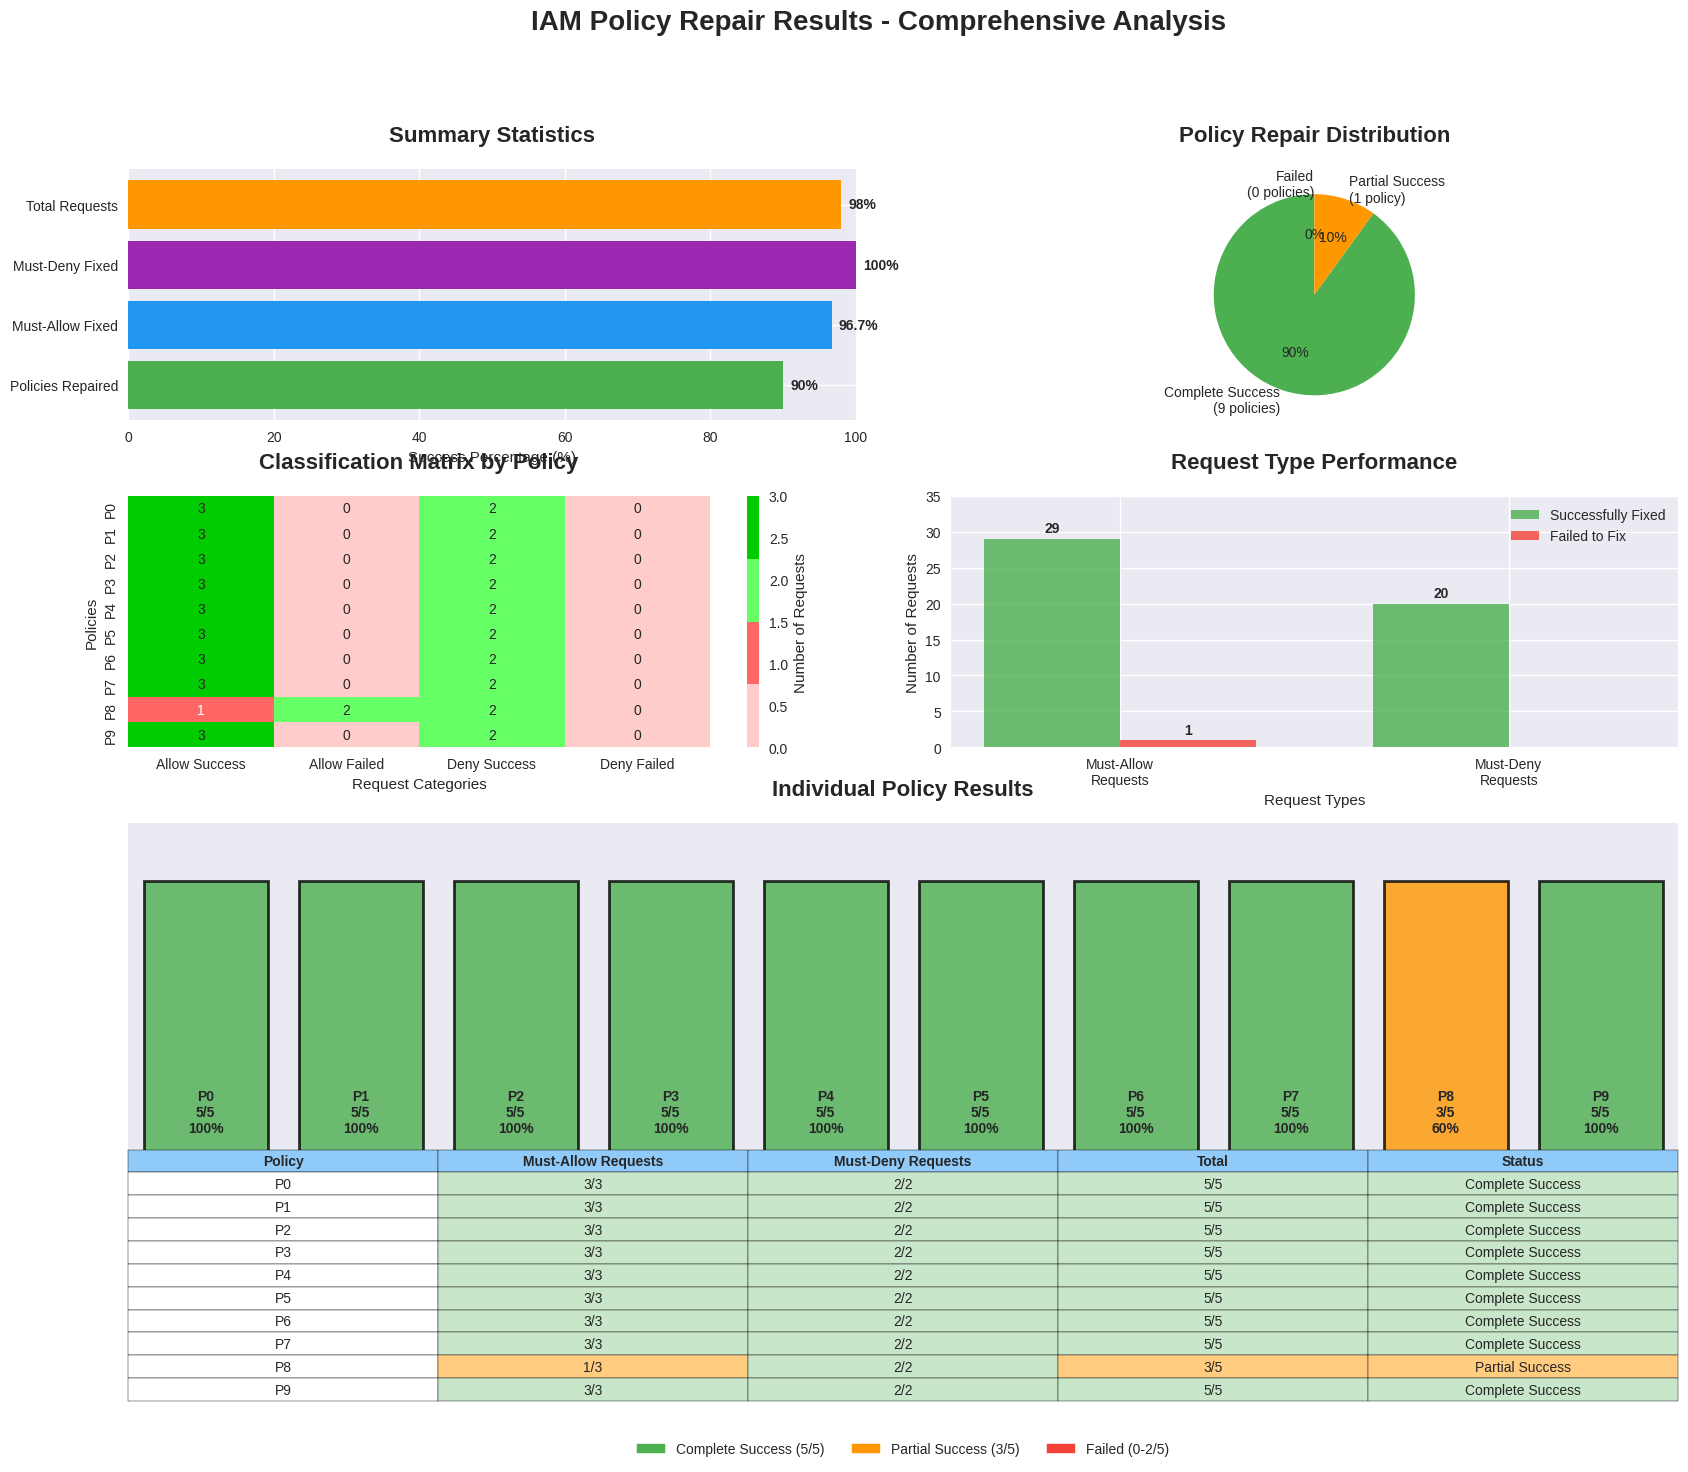

IAM POLICY REPAIR RESULTS SUMMARY
Total Policies: 10
Successfully Repaired: 9 (90%)
Partially Repaired: 1 (10%)
Failed: 0 (0%)

Request Type Breakdown:
Must-Allow Requests: 29/30 fixed (96.7%)
Must-Deny Requests: 20/20 fixed (100%)
Overall Success Rate: 49/50 (98%)

Policy-by-Policy Results:
P0: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P1: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P2: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P3: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P4: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P5: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P6: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P7: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P8: 1/3 allow, 2/2 deny, 3/5 total ⚠ Partial
P9: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data setup
policies = [f'P{i}' for i in range(10)]
must_allow_success = [3, 3, 3, 3, 3, 3, 3, 3, 1, 3]  # P8 has only 1/3
must_deny_success = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   # All policies have 2/2

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# Color scheme
colors = {
    'success': '#4CAF50',
    'partial': '#FF9800', 
    'failure': '#F44336',
    'must_allow': '#2196F3',
    'must_deny': '#9C27B0'
}

# 1. Summary Statistics (Top Left)
ax1 = fig.add_subplot(gs[0, :2])
summary_data = {
    'Policies Repaired': f'9/10 (90%)',
    'Must-Allow Fixed': f'29/30 (96.7%)',
    'Must-Deny Fixed': f'20/20 (100%)',
    'Total Requests': f'49/50 (98%)'
}

y_pos = np.arange(len(summary_data))
values = [90, 96.7, 100, 98]
bars = ax1.barh(y_pos, values, color=[colors['success'], colors['must_allow'], 
                                     colors['must_deny'], colors['partial']])

ax1.set_yticks(y_pos)
ax1.set_yticklabels(list(summary_data.keys()))
ax1.set_xlabel('Success Percentage (%)')
ax1.set_title('Summary Statistics', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 100)

# Add percentage labels on bars
for i, (bar, value) in enumerate(zip(bars, values)):
    ax1.text(value + 1, i, f'{value}%', va='center', fontweight='bold')

# 2. Policy Success Distribution Pie Chart (Top Right)
ax2 = fig.add_subplot(gs[0, 2:])
success_counts = [9, 1, 0]  # Complete, Partial, Failed
labels = ['Complete Success\n(9 policies)', 'Partial Success\n(1 policy)', 'Failed\n(0 policies)']
pie_colors = [colors['success'], colors['partial'], colors['failure']]

wedges, texts, autotexts = ax2.pie(success_counts, labels=labels, colors=pie_colors, 
                                  autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
ax2.set_title('Policy Repair Distribution', fontsize=16, fontweight='bold', pad=20)

# 3. Classification Matrix Heatmap (Middle Left)
ax3 = fig.add_subplot(gs[1, :2])

# Create matrix data
matrix_data = []
for i in range(10):
    policy_data = [must_allow_success[i], 3 - must_allow_success[i], 
                   must_deny_success[i], 2 - must_deny_success[i]]
    matrix_data.append(policy_data)

matrix_df = pd.DataFrame(matrix_data, 
                        columns=['Allow Success', 'Allow Failed', 'Deny Success', 'Deny Failed'],
                        index=policies)

# Create custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors_list = ['#ffcccc', '#ff6666', '#66ff66', '#00cc00']
n_bins = 4
cmap = LinearSegmentedColormap.from_list('custom', colors_list, N=n_bins)

sns.heatmap(matrix_df, annot=True, fmt='d', cmap=cmap, 
           cbar_kws={'label': 'Number of Requests'}, ax=ax3)
ax3.set_title('Classification Matrix by Policy', fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Request Categories')
ax3.set_ylabel('Policies')

# 4. Request Type Performance (Middle Right)
ax4 = fig.add_subplot(gs[1, 2:])

categories = ['Must-Allow\nRequests', 'Must-Deny\nRequests']
successful = [29, 20]
failed = [1, 0]
total = [30, 20]

x = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x - width/2, successful, width, label='Successfully Fixed', 
               color=colors['success'], alpha=0.8)
bars2 = ax4.bar(x + width/2, failed, width, label='Failed to Fix', 
               color=colors['failure'], alpha=0.8)

ax4.set_xlabel('Request Types')
ax4.set_ylabel('Number of Requests')
ax4.set_title('Request Type Performance', fontsize=16, fontweight='bold', pad=20)
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.set_ylim(0, 35)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}',
                    ha='center', va='bottom', fontweight='bold')

# 5. Individual Policy Results Grid (Bottom)
ax5 = fig.add_subplot(gs[2:, :])

# Create a grid visualization
grid_size = 10
x_positions = np.arange(grid_size)
y_position = 0

# Calculate success rates for each policy
policy_success_rates = [(must_allow_success[i] + must_deny_success[i]) / 5 * 100 
                       for i in range(10)]

# Create rectangles for each policy
for i, (policy, rate) in enumerate(zip(policies, policy_success_rates)):
    if rate == 100:
        color = colors['success']
        status = 'Complete'
    elif rate >= 60:
        color = colors['partial']
        status = 'Partial'
    else:
        color = colors['failure']
        status = 'Failed'
    
    # Create rectangle
    rect = Rectangle((x_positions[i] - 0.4, y_position - 0.4), 0.8, 0.8, 
                    facecolor=color, alpha=0.8, edgecolor='black', linewidth=2)
    ax5.add_patch(rect)
    
    # Add policy label
    ax5.text(x_positions[i], y_position, f'{policy}\n{must_allow_success[i]+must_deny_success[i]}/5\n{rate:.0f}%', 
            ha='center', va='center', fontweight='bold', fontsize=10)

ax5.set_xlim(-0.5, 9.5)
ax5.set_ylim(-0.5, 0.5)
ax5.set_xticks([])
ax5.set_yticks([])
ax5.set_title('Individual Policy Results', fontsize=16, fontweight='bold', pad=20)

# Add legend for policy grid
legend_elements = [
    mpatches.Patch(color=colors['success'], label='Complete Success (5/5)'),
    mpatches.Patch(color=colors['partial'], label='Partial Success (3/5)'),
    mpatches.Patch(color=colors['failure'], label='Failed (0-2/5)')
]
ax5.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# 6. Detailed Results Table
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('tight')
ax6.axis('off')

# Create table data
table_data = []
for i in range(10):
    total_success = must_allow_success[i] + must_deny_success[i]
    status = 'Complete Success' if total_success == 5 else 'Partial Success'
    table_data.append([
        f'P{i}', 
        f'{must_allow_success[i]}/3', 
        f'{must_deny_success[i]}/2', 
        f'{total_success}/5',
        status
    ])

table = ax6.table(cellText=table_data,
                 colLabels=['Policy', 'Must-Allow Requests', 'Must-Deny Requests', 'Total', 'Status'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color code the table cells
for i in range(len(table_data)):
    for j in range(len(table_data[i])):
        cell = table[(i+1, j)]
        if j == 4:  # Status column
            if 'Complete' in table_data[i][j]:
                cell.set_facecolor('#c8e6c9')
            else:
                cell.set_facecolor('#ffcc80')
        elif j in [1, 2, 3]:  # Score columns
            if '/' in table_data[i][j]:
                achieved, total = map(int, table_data[i][j].split('/'))
                if achieved == total:
                    cell.set_facecolor('#c8e6c9')
                elif achieved > 0:
                    cell.set_facecolor('#ffcc80')
                else:
                    cell.set_facecolor('#ffcdd2')

# Style header
for j in range(5):
    table[(0, j)].set_facecolor('#90caf9')
    table[(0, j)].set_text_props(weight='bold')

plt.suptitle('IAM Policy Repair Results - Comprehensive Analysis', 
             fontsize=20, fontweight='bold', y=0.98)

#save
plt.savefig('iam_policy_repair_results.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("IAM POLICY REPAIR RESULTS SUMMARY")
print("="*60)
print(f"Total Policies: 10")
print(f"Successfully Repaired: 9 (90%)")
print(f"Partially Repaired: 1 (10%)")
print(f"Failed: 0 (0%)")
print()
print("Request Type Breakdown:")
print(f"Must-Allow Requests: 29/30 fixed (96.7%)")
print(f"Must-Deny Requests: 20/20 fixed (100%)")
print(f"Overall Success Rate: 49/50 (98%)")
print()
print("Policy-by-Policy Results:")
for i in range(10):
    total = must_allow_success[i] + must_deny_success[i]
    status = "✓ Complete" if total == 5 else "⚠ Partial"
    print(f"P{i}: {must_allow_success[i]}/3 allow, {must_deny_success[i]}/2 deny, {total}/5 total {status}")
print("="*60)

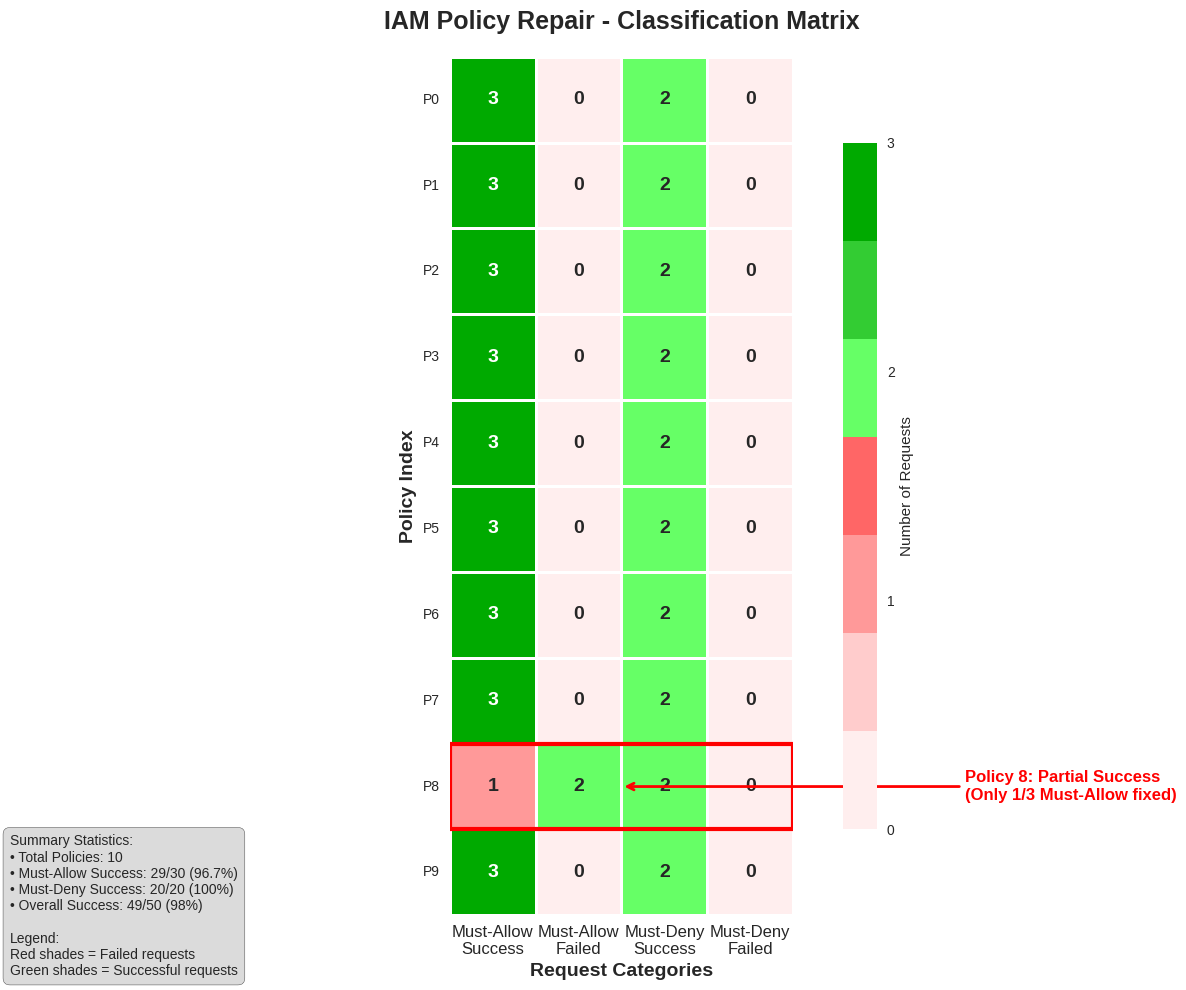

CLASSIFICATION MATRIX - DETAILED BREAKDOWN
Policy   Must-Allow      Must-Deny       Total Success   Status
--------------------------------------------------------------------------------
P0       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P1       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P2       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P3       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P4       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P5       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P6       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P7       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P8       1/3 (  33%)   2/2 ( 100%)   3/5 (  60%)   ⚠ Partial
P9       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
TOTAL:   29/30 (96.7%)    20/20 (100%)    49/50 (98.0%)    9 Complete, 1 Partial


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style for better looking plots
plt.style.use('seaborn-v0_8')

# Data setup
policies = [f'P{i}' for i in range(10)]
must_allow_success = [3, 3, 3, 3, 3, 3, 3, 3, 1, 3]  # P8 has only 1/3
must_deny_success = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   # All policies have 2/2

# Create the classification matrix data
matrix_data = []
for i in range(10):
    policy_data = [
        must_allow_success[i],      # Allow Success
        3 - must_allow_success[i],  # Allow Failed  
        must_deny_success[i],       # Deny Success
        2 - must_deny_success[i]    # Deny Failed
    ]
    matrix_data.append(policy_data)

# Create DataFrame
matrix_df = pd.DataFrame(
    matrix_data, 
    columns=['Must-Allow\nSuccess', 'Must-Allow\nFailed', 'Must-Deny\nSuccess', 'Must-Deny\nFailed'],
    index=policies
)

# Create figure
plt.figure(figsize=(12, 10))

# Create custom colormap - using discrete colors for better interpretation
from matplotlib.colors import ListedColormap
colors = ['#ffeeee', '#ffcccc', '#ff9999', '#ff6666', '#66ff66', '#33cc33', '#00aa00']
cmap = ListedColormap(colors)

# Create the heatmap
ax = sns.heatmap(
    matrix_df, 
    annot=True, 
    fmt='d', 
    cmap=cmap,
    vmin=0,
    vmax=3,
    cbar_kws={
        'label': 'Number of Requests',
        'shrink': 0.8,
        'ticks': [0, 1, 2, 3]
    },
    square=True,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)

# Customize the plot
plt.title('IAM Policy Repair - Classification Matrix', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Request Categories', fontsize=14, fontweight='bold')
plt.ylabel('Policy Index', fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(rotation=0)

# Add a text box with summary statistics
summary_text = """Summary Statistics:
• Total Policies: 10
• Must-Allow Success: 29/30 (96.7%)
• Must-Deny Success: 20/20 (100%)
• Overall Success: 49/50 (98%)

Legend:
Red shades = Failed requests
Green shades = Successful requests"""

plt.figtext(0.02, 0.02, summary_text, fontsize=10, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

# Highlight Policy 8 (the problematic one) with a border
ax.add_patch(plt.Rectangle((0, 8), 4, 1, fill=False, edgecolor='red', lw=3))

# Add arrow pointing to Policy 8
ax.annotate('Policy 8: Partial Success\n(Only 1/3 Must-Allow fixed)', 
           xy=(2, 8.5), xytext=(6, 8.5),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=12, fontweight='bold', color='red',
           ha='left', va='center')

plt.tight_layout()
plt.savefig('classification_matrix_hdpi.png', dpi=300, bbox_inches='tight')

plt.show()

#save the figure in hdpi format

# Print detailed matrix information
print("="*80)
print("CLASSIFICATION MATRIX - DETAILED BREAKDOWN")
print("="*80)
print(f"{'Policy':<8} {'Must-Allow':<15} {'Must-Deny':<15} {'Total Success':<15} {'Status'}")
print("-" * 80)

for i in range(10):
    allow_success = must_allow_success[i]
    deny_success = must_deny_success[i]
    total_success = allow_success + deny_success
    
    status = "✓ Complete" if total_success == 5 else "⚠ Partial"

    print(f"P{i:<7} {allow_success}/3 ({allow_success/3*100:4.0f}%)   "
          f"{deny_success}/2 ({deny_success/2*100:4.0f}%)   "
          f"{total_success}/5 ({total_success/5*100:4.0f}%)   {status}")

print("="*80)
print(f"TOTAL:   29/30 (96.7%)    20/20 (100%)    49/50 (98.0%)    9 Complete, 1 Partial")
print("="*80)

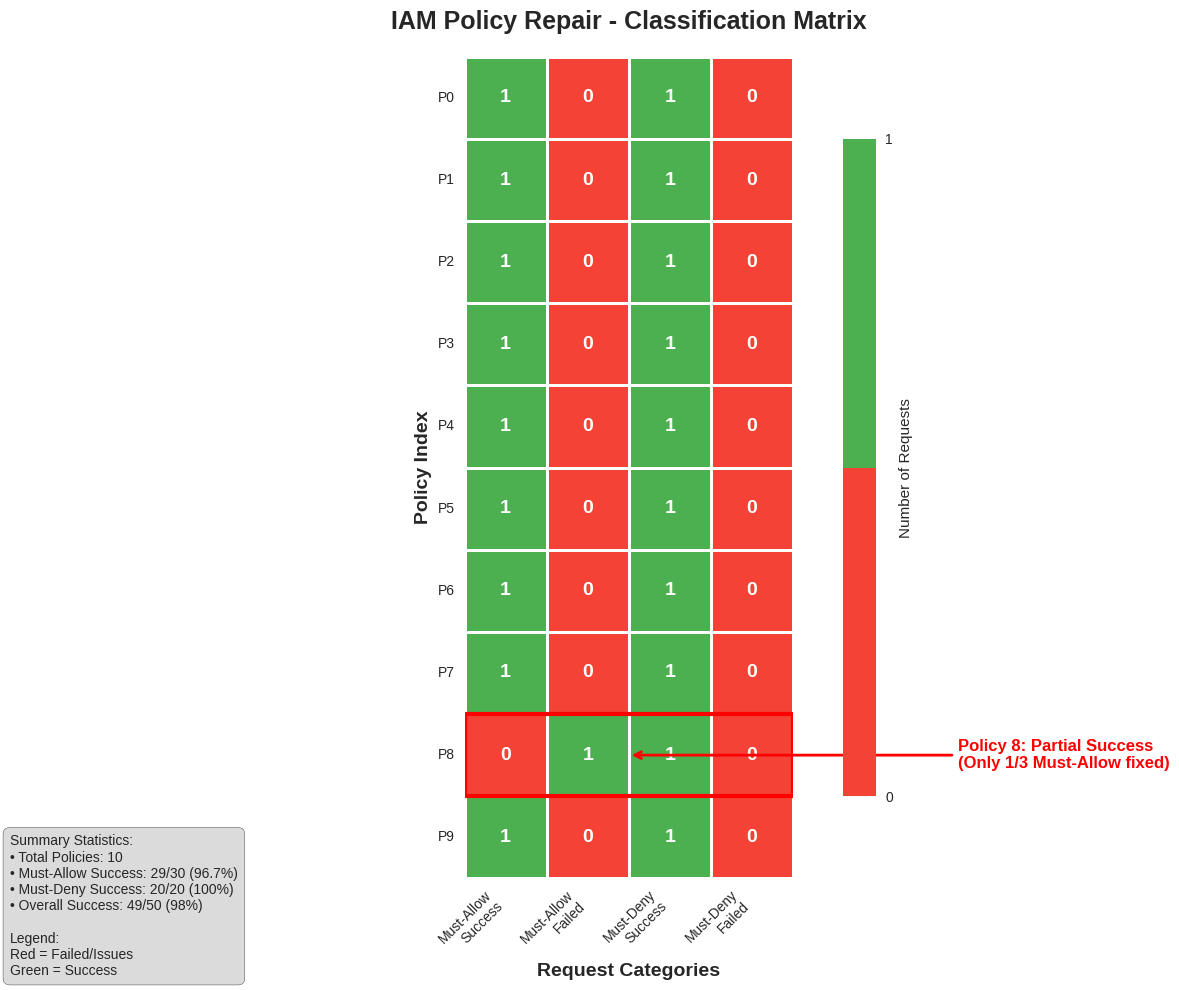

CLASSIFICATION MATRIX - DETAILED BREAKDOWN
Policy   Must-Allow      Must-Deny       Total Success   Status
--------------------------------------------------------------------------------
P0       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P1       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P2       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P3       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P4       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P5       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P6       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P7       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P8       1/3 (  33%)   2/2 ( 100%)   3/5 (  60%)   ⚠ Partial
P9       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
TOTAL:   29/30 (96.7%)    20/20 (100%)    49/50 (98.0%)    9 Complete, 1 Partial


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Set style
plt.style.use('seaborn-v0_8')

# Data setup
policies = [f'P{i}' for i in range(10)]
must_allow_success = [3, 3, 3, 3, 3, 3, 3, 3, 1, 3]  # P8 has only 1/3
must_deny_success = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   # All policies have 2/2

# Color scheme
colors = {
    'success': '#4CAF50',      # Green
    'partial': '#FF9800',      # Orange
    'failure': '#F44336',      # Red
    'excellent': '#2E7D32',    # Dark Green
}

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Grid setup
grid_cols = 5
grid_rows = 2
x_spacing = 2.5
y_spacing = 2.0

# Calculate positions for 2x5 grid
positions = []
for row in range(grid_rows):
    for col in range(grid_cols):
        x = col * x_spacing
        y = (grid_rows - 1 - row) * y_spacing  # Flip y to start from top
        positions.append((x, y))

# Calculate success rates and create policy boxes
for i, (policy, pos) in enumerate(zip(policies, positions)):
    total_success = must_allow_success[i] + must_deny_success[i]
    success_rate = total_success / 5 * 100
    
    # Determine color and status based on success rate
    if success_rate == 100:
        color = colors['success']
        status = 'Complete'
        border_color = colors['excellent']
        border_width = 3
    elif success_rate >= 60:
        color = colors['partial']
        status = 'Partial'
        border_color = colors['partial']
        border_width = 3
    else:
        color = colors['failure']
        status = 'Failed'
        border_color = colors['failure']
        border_width = 3
    
    # Create rectangle for policy box
    rect = Rectangle((pos[0] - 0.8, pos[1] - 0.6), 1.6, 1.2, 
                    facecolor=color, alpha=0.8, 
                    edgecolor=border_color, linewidth=border_width)
    ax.add_patch(rect)
    
    # Add policy information text
    policy_text = f'{policy}\n{total_success}/5\n{success_rate:.0f}%\n{status}'
    ax.text(pos[0], pos[1], policy_text, 
            ha='center', va='center', fontweight='bold', 
            fontsize=12, color='white' if success_rate == 100 else 'black')
    
    # Add breakdown text below each box
    breakdown_text = f'Allow: {must_allow_success[i]}/3\nDeny: {must_deny_success[i]}/2'
    ax.text(pos[0], pos[1] - 1.0, breakdown_text, 
            ha='center', va='center', fontsize=9, 
            style='italic', color='gray')

# Set plot limits and remove axes
ax.set_xlim(-1.5, grid_cols * x_spacing - 1.5)
ax.set_ylim(-1.5, grid_rows * y_spacing - 0.5)
ax.set_aspect('equal')
ax.axis('off')

# Add title
plt.title('Individual Policy Results - Repair Success Overview', 
          fontsize=18, fontweight='bold', pad=30)

# Create legend
legend_elements = [
    mpatches.Patch(color=colors['success'], label='Complete Success (5/5 requests)'),
    mpatches.Patch(color=colors['partial'], label='Partial Success (3/5 requests)'),
    mpatches.Patch(color=colors['failure'], label='Failed (0-2/5 requests)')
]

ax.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=12,
          frameon=True, fancybox=True, shadow=True)

# Add summary statistics box
summary_stats = f"""Overall Statistics:
✓ Complete Success: 9/10 policies (90%)
⚠ Partial Success: 1/10 policies (10%)
✗ Failed: 0/10 policies (0%)

Request Success Rate: 49/50 (98%)"""

ax.text(0.02, 0.98, summary_stats, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

# Highlight Policy 8 with special annotation
arrow_props = dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                  color='red', lw=2)
ax.annotate('Only policy with\npartial success', 
           xy=positions[8], xytext=(positions[8][0] + 3, positions[8][1] + 1),
           arrowprops=arrow_props,
           fontsize=11, fontweight='bold', color='red',
           ha='center', va='center',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

# Print individual policy breakdown
print("="*70)
print("INDIVIDUAL POLICY RESULTS - DETAILED BREAKDOWN")
print("="*70)
print(f"{'Policy':<8} {'Must-Allow':<12} {'Must-Deny':<11} {'Total':<8} {'Rate':<8} {'Status'}")
print("-" * 70)

for i in range(10):
    allow_success = must_allow_success[i]
    deny_success = must_deny_success[i]
    total_success = allow_success + deny_success
    success_rate = total_success / 5 * 100
    
    if success_rate == 100:
        status = "✓ Complete"
        status_icon = "🟢"
    elif success_rate >= 60:
        status = "⚠ Partial"
        status_icon = "🟡"
    else:
        status = "✗ Failed"
        status_icon = "🔴"
    
    print(f"{status_icon} P{i:<6} {allow_success}/3 ({allow_success/3*100:3.0f}%)   "
          f"{deny_success}/2 ({deny_success/2*100:3.0f}%)   "
          f"{total_success}/5   {success_rate:5.0f}%   {status}")

print("="*70)
print("Legend: 🟢 Complete Success | 🟡 Partial Success | 🔴 Failed")
print("="*70)

# Additional analysis
print("\nKEY INSIGHTS:")
print("• Policy 8 is the only outlier with 2 failed must-allow requests")
print("• All policies successfully handled must-deny requests (100% success)")
print("• Must-allow requests had 96.7% success rate (29/30)")
print("• Overall system achieved 98% request success rate")